## Imports

In [7]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


In [8]:
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1. Define the same UNet model we trained
# -------------------------

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.d1 = ConvBlock(1, 32)
        self.p1 = nn.MaxPool2d(2)

        self.d2 = ConvBlock(32, 64)
        self.p2 = nn.MaxPool2d(2)

        self.d3 = ConvBlock(64, 128)
        self.p3 = nn.MaxPool2d(2)

        self.d4 = ConvBlock(128, 256)
        self.p4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bn = ConvBlock(256, 512)

        # Decoder
        self.u4 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.c4 = ConvBlock(256 + 256, 256)

        self.u3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.c3 = ConvBlock(128 + 128, 128)

        self.u2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.c2 = ConvBlock(64 + 64, 64)

        self.u1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.c1 = ConvBlock(32 + 32, 32)

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        d1 = self.d1(x)
        p1 = self.p1(d1)

        d2 = self.d2(p1)
        p2 = self.p2(d2)

        d3 = self.d3(p2)
        p3 = self.p3(d3)

        d4 = self.d4(p3)
        p4 = self.p4(d4)

        bn = self.bn(p4)

        u4 = self.u4(bn)
        c4 = self.c4(torch.cat([u4, d4], dim=1))

        u3 = self.u3(c4)
        c3 = self.c3(torch.cat([u3, d3], dim=1))

        u2 = self.u2(c3)
        c2 = self.c2(torch.cat([u2, d2], dim=1))

        u1 = self.u1(c2)
        c1 = self.c1(torch.cat([u1, d1], dim=1))

        return self.out(c1)

## Corruption Functions - For artificial shadows

In [9]:
def add_gaussian_noise(img, sigma=0.03):
    # img is already a torch tensor
    noise = torch.randn_like(img, dtype=torch.float32) * sigma
    return torch.clamp(img + noise, 0.0, 1.0)


def add_gaussian_blur(img, kernel=5, sigma=1.0):
    # Convert to numpy float32
    img_np = img.squeeze().cpu().numpy().astype(np.float32)

    img_np = cv2.GaussianBlur(img_np, (kernel, kernel), sigma)

    # Back to torch float32
    return torch.tensor(img_np, dtype=torch.float32).unsqueeze(0)


def add_bias_field(img, strength=0.15):
    h, w = img.shape[-2:]

    # Explicit float32 bias
    bias = np.random.randn(h, w).astype(np.float32)
    bias = cv2.GaussianBlur(bias, (0, 0), sigmaX=32)

    bias = bias / (np.max(np.abs(bias)) + 1e-6)
    bias = 1.0 + strength * bias

    img_np = img.squeeze().cpu().numpy().astype(np.float32)
    img_np = img_np * bias
    img_np = np.clip(img_np, 0.0, 1.0)

    return torch.tensor(img_np, dtype=torch.float32).unsqueeze(0)


def corrupt_patch(img):
    # Always keep float32
    img = img.float()

    if torch.rand(1) < 0.7:
        img = add_gaussian_noise(img)

    if torch.rand(1) < 0.5:
        img = add_gaussian_blur(img)

    if torch.rand(1) < 0.5:
        img = add_bias_field(img)

    return img.float()


## Phase-1 Dataset

In [10]:
class Phase1Dataset(Dataset):
    def __init__(self, image_dir, patch_size=128, samples_per_image=50):
        self.image_dir = image_dir
        self.patch_size = patch_size
        self.samples = []

        image_files = sorted([
            f for f in os.listdir(image_dir)
            if f.lower().endswith((".tif", ".png", ".jpg", ".jpeg"))
        ])

        for fname in image_files:
            path = os.path.join(image_dir, fname)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = img.astype(np.float32) / 255.0
            h, w = img.shape

            for _ in range(samples_per_image):
                y = np.random.randint(0, h - patch_size)
                x = np.random.randint(0, w - patch_size)
                patch = img[y:y+patch_size, x:x+patch_size]
                self.samples.append(patch)

        print(f"Phase 1 patches created: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        clean = torch.tensor(self.samples[idx], dtype=torch.float32).unsqueeze(0)
        noisy = corrupt_patch(clean.clone()).float()
        return noisy, clean



## Dataloader

In [11]:
PHASE1_IMAGE_DIR = r"C:\Users\User\OneDrive\Documents\MATLAB\Matlab Data\solder_ball_data"

train_ds = Phase1Dataset(
    PHASE1_IMAGE_DIR,
    patch_size=128,
    samples_per_image=50
)

train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)


Phase 1 patches created: 5600


## Train Phase-1

In [12]:
model = UNet().to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 30
model.train()

for epoch in range(1, EPOCHS + 1):
    running_loss = 0

    for inp, tar in tqdm(train_loader, desc=f"Epoch {epoch}"):
        inp, tar = inp.to(device), tar.to(device)

        optimizer.zero_grad()
        out = model(inp)
        loss = criterion(out, tar)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch:02d} | L1 Loss: {running_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), "phase1_geom.pth")
print("✅ Phase 1 complete. Saved: phase1_geom.pth")


Epoch 1: 100%|███████████████████████████████████████████████████████████████████████| 700/700 [01:02<00:00, 11.19it/s]


Epoch 01 | L1 Loss: 0.0345


Epoch 2: 100%|███████████████████████████████████████████████████████████████████████| 700/700 [01:01<00:00, 11.47it/s]


Epoch 02 | L1 Loss: 0.0187


Epoch 3: 100%|███████████████████████████████████████████████████████████████████████| 700/700 [01:00<00:00, 11.49it/s]


...

Epoch 28 | L1 Loss: 0.0168


Epoch 29: 100%|██████████████████████████████████████████████████████████████████████| 700/700 [01:00<00:00, 11.65it/s]


Epoch 29 | L1 Loss: 0.0170


Epoch 30: 100%|██████████████████████████████████████████████████████████████████████| 700/700 [01:00<00:00, 11.56it/s]

Epoch 30 | L1 Loss: 0.0165
✅ Phase 1 complete. Saved: phase1_geom.pth


## Phase-2

In [13]:
model = UNet().to(device)

ckpt = torch.load("phase1_geom.pth", map_location=device)
model.load_state_dict(ckpt)

model.train()
print("✔ Loaded Phase-1 geometric weights")


C:\Users\User\AppData\Local\Temp\ipykernel_2736\3541667740.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("phase1_geom.pth", map_location=device)


✔ Loaded Phase-1 geometric weights


## Shadow Corruption Functions

In [87]:
import cv2
import torch
import torch.nn.functional as F
import numpy as np


def add_lowfreq_directional_shadow(img, strength_range=(0.25, 0.45)):
    """
    Very smooth global illumination gradient.
    """
    _, H, W = img.shape
    device = img.device

    strength = torch.empty(1).uniform_(*strength_range).item()
    angle = torch.empty(1).uniform_(0, np.pi).item()

    x = torch.linspace(-1, 1, W, device=device)
    y = torch.linspace(-1, 1, H, device=device)
    xv, yv = torch.meshgrid(x, y, indexing="xy")

    grad = torch.cos(angle) * xv + torch.sin(angle) * yv
    grad = (grad - grad.min()) / (grad.max() - grad.min())

    shadow = 1.0 - strength * grad
    shadow = shadow.unsqueeze(0)

    # VERY large blur → guarantees low-frequency only
    k = int(min(H, W) * 0.6) | 1
    shadow = cv2.GaussianBlur(
        shadow.squeeze().cpu().numpy(),
        (k, k),
        sigmaX=k // 2
    )
    shadow = torch.tensor(shadow, device=device).unsqueeze(0)

    return torch.clamp(img * shadow, 0, 1)


def add_lowfreq_bias_shadow(img, strength_range=(0.15, 0.35)):
    """
    Extremely smooth multiplicative bias field.
    """
    _, H, W = img.shape
    device = img.device

    strength = torch.empty(1).uniform_(*strength_range).item()

    bias = torch.randn((H, W), device=device)
    bias = bias / bias.abs().max()

    k = int(min(H, W) * 0.7) | 1
    bias = cv2.GaussianBlur(
        bias.cpu().numpy(),
        (k, k),
        sigmaX=k // 2
    )

    bias = torch.tensor(bias, device=device)
    shadow = 1.0 - strength * bias
    shadow = shadow.unsqueeze(0)

    return torch.clamp(img * shadow, 0, 1)


def corrupt_patch_phase2(img):
    """
    Change-1 corruption:
    ONLY low-frequency illumination effects.
    """
    img = img.float()

    # Always one global illumination gradient
    img = add_lowfreq_directional_shadow(img)

    # Sometimes add an extra smooth bias
    if torch.rand(1) < 0.5:
        img = add_lowfreq_bias_shadow(img)

    # Very small sensor noise (optional)
    if torch.rand(1) < 0.2:
        img = img + 0.01 * torch.randn_like(img)

    return torch.clamp(img, 0, 1)


## Phase-2 Dataset

In [88]:
class Phase2Dataset(Dataset):
    def __init__(self, clean_patches, shadows_per_clean=4):
        self.clean_patches = clean_patches
        self.shadows_per_clean = shadows_per_clean

    def __len__(self):
        # each clean patch appears multiple times with different shadows
        return len(self.clean_patches) * self.shadows_per_clean

    def __getitem__(self, idx):
        clean_idx = idx // self.shadows_per_clean

        clean = torch.tensor(
            self.clean_patches[clean_idx],
            dtype=torch.float32
        ).unsqueeze(0)

        shadowed = corrupt_patch_phase2(clean.clone())

        return shadowed, clean


## Training setup with lower learning rate 

In [89]:
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)  # lower LR
EPOCHS = 25


## Helper Function

In [90]:
def gradient_loss(pred, target):
    # Horizontal gradients
    dx_pred = torch.abs(pred[:, :, :, 1:] - pred[:, :, :, :-1])
    dx_tgt  = torch.abs(target[:, :, :, 1:] - target[:, :, :, :-1])

    # Vertical gradients
    dy_pred = torch.abs(pred[:, :, 1:, :] - pred[:, :, :-1, :])
    dy_tgt  = torch.abs(target[:, :, 1:, :] - target[:, :, :-1, :])

    return torch.mean(torch.abs(dx_pred - dx_tgt)) + \
           torch.mean(torch.abs(dy_pred - dy_tgt))


## Train phase-2

In [91]:
from tqdm import tqdm

model.train()

for epoch in range(1, EPOCHS + 1):
    running_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}", leave=True)

    for inp, tar in pbar:
        inp = inp.to(device).float()
        tar = tar.to(device).float()

        optimizer.zero_grad()
        out = model(inp)
        l1 = criterion(out, tar)
        g  = gradient_loss(out, tar)
        loss = 0.7 * l1 + 0.3 * g
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix(L1=loss.item())

    epoch_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch:02d} | L1 Loss: {epoch_loss:.4f}")


Epoch 1: 100%|███████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 14.82it/s, L1=0.1]


Epoch 01 | L1 Loss: 0.0759


Epoch 2: 100%|████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 30.23it/s, L1=0.0773]


Epoch 02 | L1 Loss: 0.0745


Epoch 3: 100%|████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 30.83it/s, L1=0.0581]


...

Epoch 23 | L1 Loss: 0.0649


Epoch 24: 100%|███████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 30.27it/s, L1=0.0768]


Epoch 24 | L1 Loss: 0.0660


Epoch 25: 100%|████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 31.50it/s, L1=0.071]

Epoch 25 | L1 Loss: 0.0644


In [92]:
torch.save(model.state_dict(), "phase2_shadow.pth")
print("✅ Phase 2 complete. Saved: phase2_shadow.pth")


✅ Phase 2 complete. Saved: phase2_shadow.pth


# Phase - 3 - Final Model 

### Imports and device 

In [93]:
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from math import log10

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


## U-Net Model

In [94]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.d1 = ConvBlock(1, 32)
        self.p1 = nn.MaxPool2d(2)

        self.d2 = ConvBlock(32, 64)
        self.p2 = nn.MaxPool2d(2)

        self.d3 = ConvBlock(64, 128)
        self.p3 = nn.MaxPool2d(2)

        self.d4 = ConvBlock(128, 256)
        self.p4 = nn.MaxPool2d(2)

        self.bn = ConvBlock(256, 512)

        self.u4 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.c4 = ConvBlock(512, 256)

        self.u3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.c3 = ConvBlock(256, 128)

        self.u2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.c2 = ConvBlock(128, 64)

        self.u1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.c1 = ConvBlock(64, 32)

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        d1 = self.d1(x)
        d2 = self.d2(self.p1(d1))
        d3 = self.d3(self.p2(d2))
        d4 = self.d4(self.p3(d3))
        bn = self.bn(self.p4(d4))

        u4 = self.c4(torch.cat([self.u4(bn), d4], dim=1))
        u3 = self.c3(torch.cat([self.u3(u4), d3], dim=1))
        u2 = self.c2(torch.cat([self.u2(u3), d2], dim=1))
        u1 = self.c1(torch.cat([self.u1(u2), d1], dim=1))

        return self.out(u1)


##  Load phase-2 weights 

In [95]:
model = UNet().to(device)

ckpt = torch.load("phase2_shadow.pth", map_location=device)

# ---- Key remapping: conv → block ----
new_ckpt = {}
for k, v in ckpt.items():
    new_k = k.replace("conv", "block")
    new_ckpt[new_k] = v

model.load_state_dict(new_ckpt, strict=False)
model.train()

print("✔ Loaded Phase-2 shadow-aware weights (remapped keys)")


✔ Loaded Phase-2 shadow-aware weights (remapped keys)


C:\Users\User\AppData\Local\Temp\ipykernel_2736\3941316304.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("phase2_shadow.pth", map_location=device)


## PatchDataset

In [96]:
class PatchDataset(Dataset):
    def __init__(self, root_dir, split, augment=False):
        self.augment = augment
        self.input_dir = os.path.join(root_dir, split, "input")
        self.target_dir = os.path.join(root_dir, split, "target")
        self.files = sorted(os.listdir(self.input_dir))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]

        inp = cv2.imread(os.path.join(self.input_dir, fname), 0).astype(np.float32) / 255.0
        tar = cv2.imread(os.path.join(self.target_dir, fname), 0).astype(np.float32) / 255.0

        inp = torch.tensor(inp, dtype=torch.float32).unsqueeze(0)
        tar = torch.tensor(tar, dtype=torch.float32).unsqueeze(0)

        if self.augment:
            if torch.rand(1) < 0.5:
                inp = TF.hflip(inp)
                tar = TF.hflip(tar)
            if torch.rand(1) < 0.5:
                inp = TF.vflip(inp)
                tar = TF.vflip(tar)

        return inp, tar


## Dataloaders

In [97]:
train_ds = PatchDataset(r"C:\Users\User\OneDrive\Documents\Shadow Removal\Shadow_Removal\dataset_v2", "train", augment=True)
val_ds   = PatchDataset(r"C:\Users\User\OneDrive\Documents\Shadow Removal\Shadow_Removal\dataset_v2", "val", augment=False)

train_loader = DataLoader(
    train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0
)

print("Train:", len(train_ds), " Val:", len(val_ds))


Train: 14  Val: 3


## Loass Optimizer Metrics

In [100]:
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
EPOCHS = 25

def psnr(pred, gt):
    mse = torch.mean((pred - gt) ** 2).item()
    if mse == 0:
        return 100
    return 10 * log10(1 / mse)

def compute_ssim(pred, gt):
    p = pred.squeeze().cpu().numpy()
    g = gt.squeeze().cpu().numpy()
    return ssim(p, g, data_range=1)


## Training Loop

In [101]:
best_val = 999

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}")
    for inp, tar in pbar:
        inp = inp.to(device)
        tar = tar.to(device)

        optimizer.zero_grad()
        out = model(inp)
        loss = criterion(out, tar)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        pbar.set_postfix(L1=loss.item())

    train_loss /= len(train_loader)

    # ---- Validation ----
    model.eval()
    val_loss = 0
    val_psnr = 0
    val_ssim = 0

    with torch.no_grad():
        for inp, tar in val_loader:
            inp = inp.to(device)
            tar = tar.to(device)
            out = model(inp)

            loss = criterion(out, tar)
            val_loss += loss.item()
            val_psnr += psnr(out, tar)
            val_ssim += compute_ssim(out, tar)

    val_loss /= len(val_loader)
    val_psnr /= len(val_loader)
    val_ssim /= len(val_loader)

    print(f"Epoch {epoch:02d} | Train L1: {train_loss:.4f} | "
          f"Val L1: {val_loss:.4f} | PSNR: {val_psnr:.2f} | SSIM: {val_ssim:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "final_tri_model.pth")
        print(" Saved best TRI-specialized model")


Epoch 1: 100%|████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 12.05it/s, L1=0.0667]


Epoch 01 | Train L1: 0.0640 | Val L1: 0.1040 | PSNR: 17.20 | SSIM: 0.4278
 Saved best TRI-specialized model


Epoch 2: 100%|████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 30.37it/s, L1=0.0621]


Epoch 02 | Train L1: 0.0650 | Val L1: 0.1041 | PSNR: 17.19 | SSIM: 0.4294


Epoch 3: 100%|█████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 31.41it/s, L1=0.062]


...

Epoch 23 | Train L1: 0.0631 | Val L1: 0.1035 | PSNR: 17.24 | SSIM: 0.4300


Epoch 24: 100%|███████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 32.53it/s, L1=0.0629]


Epoch 24 | Train L1: 0.0630 | Val L1: 0.1044 | PSNR: 17.17 | SSIM: 0.4287


Epoch 25: 100%|████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 32.46it/s, L1=0.064]


Epoch 25 | Train L1: 0.0628 | Val L1: 0.1034 | PSNR: 17.25 | SSIM: 0.4294


## Run the final model 

In [102]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet().to(device)

ckpt = torch.load("final_tri_model.pth", map_location=device)

# remap keys if needed (conv → block)
new_ckpt = {k.replace("conv", "block"): v for k, v in ckpt.items()}
model.load_state_dict(new_ckpt, strict=False)

model.eval()
print("✔ Final TRI model loaded")


✔ Final TRI model loaded


C:\Users\User\AppData\Local\Temp\ipykernel_2736\3608308115.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("final_tri_model.pth", map_location=device)

In [103]:
def run_unet_on_full_image(
    model,
    img_path,
    patch_size=128,
    overlap=96
):
    img = cv2.imread(img_path, 0)
    h, w = img.shape

    img_f = img.astype(np.float32) / 255.0

    out = np.zeros((h, w), np.float32)
    count = np.zeros((h, w), np.float32)

    step = patch_size - overlap

    for i in range(0, h - patch_size + 1, step):
        for j in range(0, w - patch_size + 1, step):

            patch = img_f[i:i+patch_size, j:j+patch_size]
            patch_t = torch.tensor(patch).unsqueeze(0).unsqueeze(0).to(device)

            with torch.no_grad():
                pred = model(patch_t).cpu().squeeze().numpy()

            out[i:i+patch_size, j:j+patch_size] += pred
            count[i:i+patch_size, j:j+patch_size] += 1

    out = out / count
    out = np.clip(out * 255, 0, 255).astype(np.uint8)

    return img, out


C:\Users\User\AppData\Local\Temp\ipykernel_2736\3899180288.py:29: RuntimeWarning: invalid value encountered in divide
  out = out / count
C:\Users\User\AppData\Local\Temp\ipykernel_2736\3899180288.py:30: RuntimeWarning: invalid value encountered in cast
  out = np.clip(out * 255, 0, 255).astype(np.uint8)


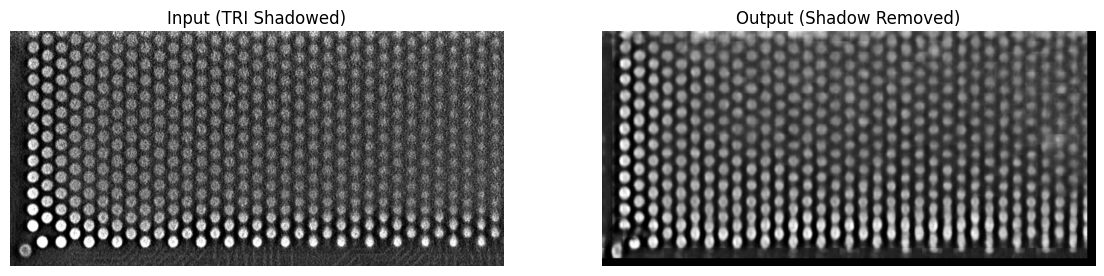

Saved: image1_final.jpeg


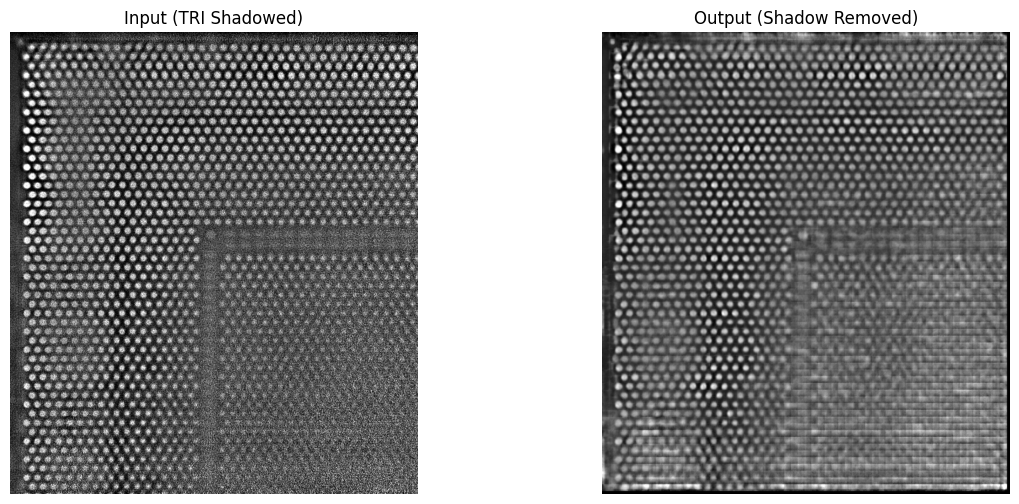

Saved: image2_final.bmp


In [104]:
tri_images = [
    r"C:\Users\User\OneDrive\Documents\Shadow Removal\Shadow_Removal\image1.jpeg",
    r"C:\Users\User\OneDrive\Documents\Shadow Removal\Shadow_Removal\image2.bmp",

]

for img_path in tri_images:
    inp, out = run_unet_on_full_image(model, img_path)

    plt.figure(figsize=(14,6))
    plt.subplot(1,2,1)
    plt.title("Input (TRI Shadowed)")
    plt.imshow(inp, cmap="gray")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Output (Shadow Removed)")
    plt.imshow(out, cmap="gray")
    plt.axis("off")

    plt.show()

    save_name = os.path.basename(img_path).replace(".", "_final.")
    cv2.imwrite(save_name, out)
    print("Saved:", save_name)
